In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

SCALING_WEIGHTS = [100/15, 100/8, 100/100]

In [2]:
data = pd.read_pickle("ml_data_onsite_start.pickle")
for key in data.keys():
    print(key)

X
y


In [3]:
for key in data["X"].keys():
    print(key)

train
val
live_test


In [4]:
for key in data["y"].keys():
    print(key)

train
val


In [5]:
X_train = data["X"]["train"]
y_train = data["y"]["train"]

X_val = data["X"]["val"]
y_val = data["y"]["val"]

X_test = data["X"]["live_test"]

In [6]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape

((2024, 5, 5, 5, 6), (2024, 3), (376, 5, 5, 5, 6), (376, 3), (200, 5, 5, 5, 6))

In [7]:
def vis(arr):
    plt.figure(figsize=(8, 8))

    cnt = 1
    for z in range(5):
        for q in range(6):
            plt.subplot(5, 6, cnt)
            plt.imshow(arr[:, :, z, q], vmin=-40, vmax=40, cmap='hsv')
            plt.grid()
            plt.axis('off')
            cnt += 1

    plt.tight_layout()

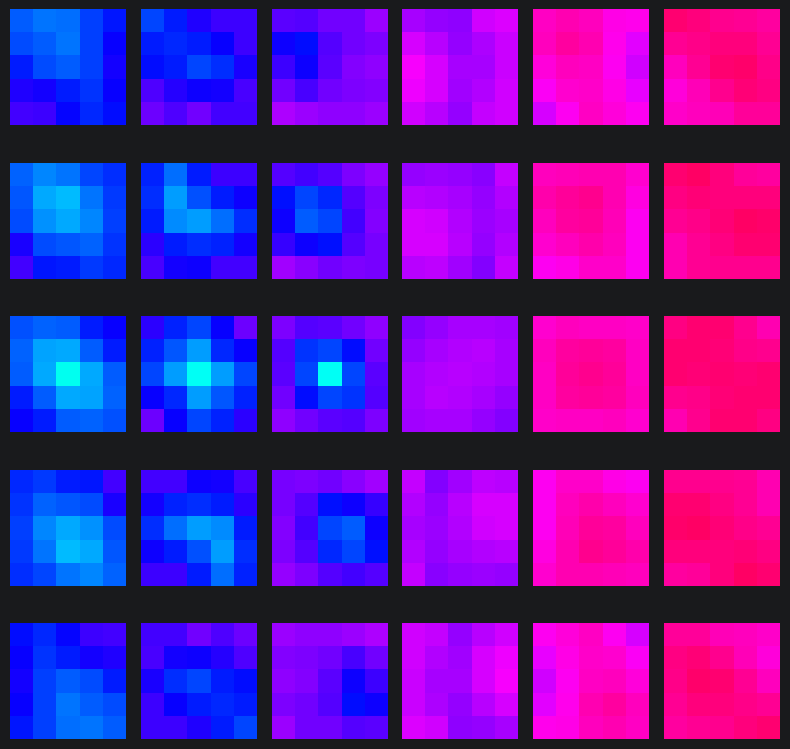

In [8]:
vis(X_train[0])

In [70]:
print(X_train.shape)
print(y_train.shape)

print("Min:", X_train.min())
print("Max:", X_train.max())
print("Mean:", X_train.mean())
print("Std:", X_train.std())

print("Targets:")
print(pd.DataFrame(y_train).describe())

(2024, 5, 5, 5, 6)
(2024, 3)
Min: -14.4009822477
Max: 101.0012400287
Mean: 28.637439957560943
Std: 17.28319174083578
Targets:
                 0            1            2
count  2024.000000  2024.000000  2024.000000
mean     -1.035139     1.460841    11.546200
std       3.507827     5.941608    14.155502
min     -20.736600   -31.017100    -0.106002
25%      -1.699156    -1.465189     4.450752
50%      -0.111445     0.828237     6.684437
75%       0.529047     4.349978    11.084964
max       7.222572    18.540382   231.245026


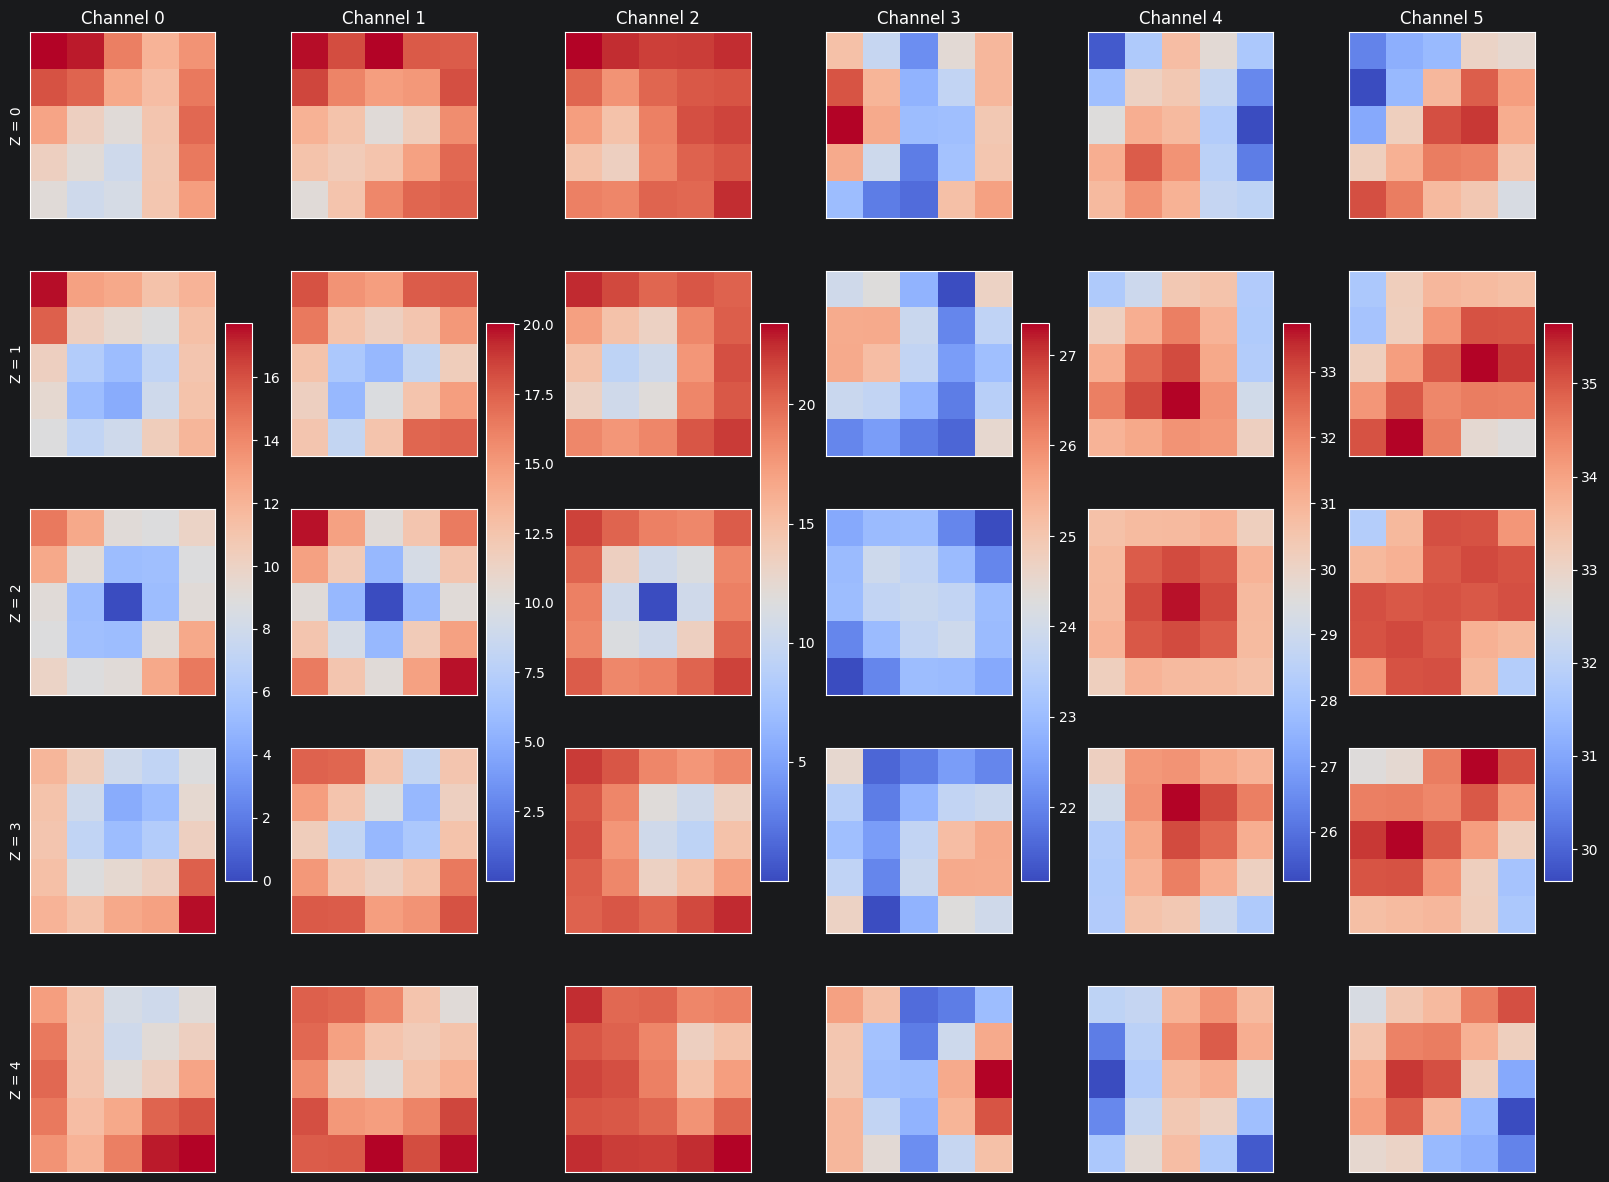

In [71]:
def visualize_cube(cube):
    fig, axes = plt.subplots(
        5, 6,
        figsize=(16, 12),
        constrained_layout=True
    )

    for channel in range(6):
        values = cube[:, :, :, channel]

        vmin = values.min()
        vmax = values.max()

        for z in range(5):
            ax = axes[z, channel]

            im = ax.imshow(
                cube[:, :, z, channel],
                cmap="coolwarm",
                vmin=vmin,
                vmax=vmax,
                origin="lower"
            )

            if z == 0:
                ax.set_title(f"Channel {channel}")

            if channel == 0:
                ax.set_ylabel(f"Z = {z}")

            ax.set_xticks([])
            ax.set_yticks([])

        fig.colorbar(
            im,
            ax=axes[:, channel],
            shrink=0.7
        )

    plt.show()

visualize_cube(X_train[0])

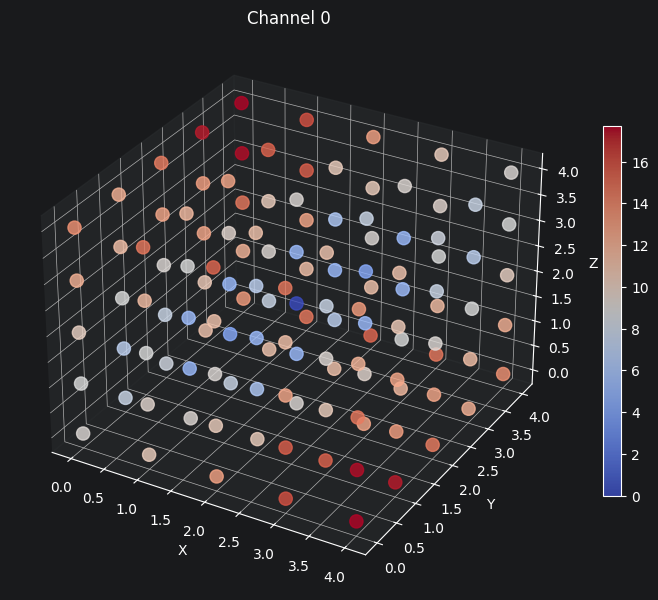

In [72]:
def visualize_3d(cube, channel=0):
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    x, y, z = np.indices((5, 5, 5))

    values = cube[:, :, :, channel]

    scatter = ax.scatter(
        x.ravel(),
        y.ravel(),
        z.ravel(),
        c=values.ravel(),
        cmap="coolwarm",
        s=90,
        alpha=0.8
    )

    fig.colorbar(scatter, ax=ax, shrink=0.6)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    ax.set_title(f"Channel {channel}")

    plt.show()

visualize_3d(X_train[0], channel=0)

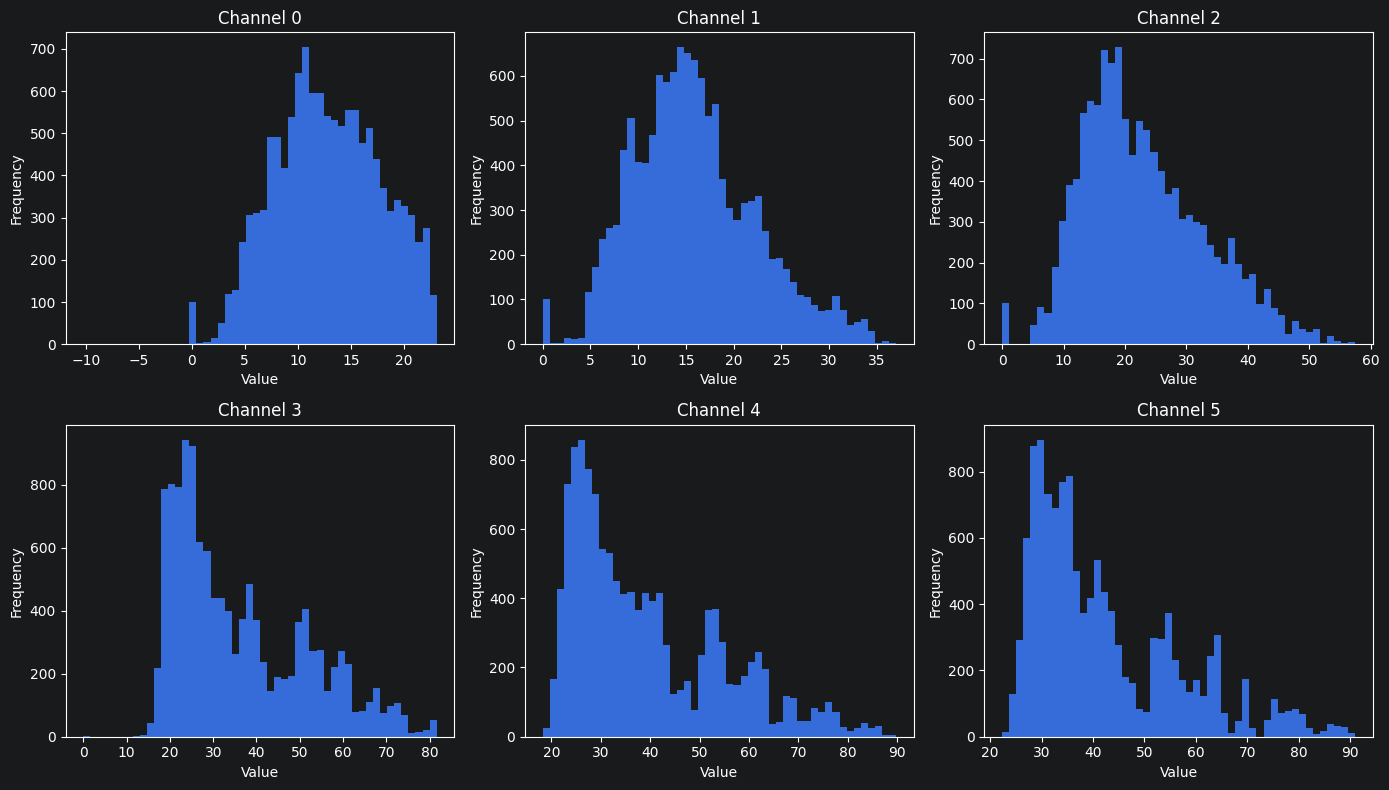

In [73]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8)
)

for channel, ax in enumerate(axes.flat):
    values = X_train[:100, :, :, :, channel].ravel()

    ax.hist(values, bins=50)

    ax.set_title(f"Channel {channel}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [9]:
# Result evaluation / writing predictions

def test_solution(X_train, y_train, X_val, y_val, feature_num=0):
    assert X_train.shape[-1] <= 300, "Too many features! Should be less than 300"
    assert X_val.shape[-1] <= 300, "Too many features! Should be less than 300"

    model =  LinearRegression().fit(
        X_train,
        y_train[:, feature_num]
    )
    predictions = model.predict(X_val)
    rmse = mean_squared_error(
        predictions,
        y_val[:, feature_num]
    )**.5
    normalized_rmse = rmse * SCALING_WEIGHTS[feature_num]
    print(f"Property #{feature_num}:    raw RMSE={rmse:.6f}")
    print(f"Property #{feature_num}: scaled RMSE={normalized_rmse:.6f}")
    return round(normalized_rmse, 6)

In [85]:
# features compression

def extract_features(X):
    means = (X**3).mean(axis=(1, 2, 3))
    stds = (X**3).std(axis=(1, 2, 3))
    maxs = (X).max(axis=(1, 2, 3))
    mins = (X).min(axis=(1, 2, 3))

    return np.concatenate(
        [means, stds, maxs, mins],
        axis=1
    )

In [86]:
%%time
total_score = 0
for feature_number in range(3):
  total_score += test_solution(
      extract_features(X_train),
      y_train,
      extract_features(X_val),
      y_val,
      feature_num=feature_number
  )
  print()
total_score /= 3
print('='*16)
print(f"Total score = {total_score:.6f}")

Property #0:    raw RMSE=0.532133
Property #0: scaled RMSE=3.547557

Property #1:    raw RMSE=0.099850
Property #1: scaled RMSE=1.248127

Property #2:    raw RMSE=1.119296
Property #2: scaled RMSE=1.119296

Total score = 1.971660
CPU times: user 803 ms, sys: 0 ns, total: 803 ms
Wall time: 185 ms


In [46]:
def dummy_feature_extractor(X):
    X_new = X.reshape((X.shape[0], -1)) # ravel
    X_new = X_new[:, :300] # pick first 300 features
    return X_new

dummy_feature_extractor(X_train).shape

(2024, 18)

In [51]:
%%time
total_score = 0
for feature_number in range(3):
  total_score += test_solution(
      dummy_feature_extractor(X_train),
      y_train,
      dummy_feature_extractor(X_val),
      y_val,
      feature_num=feature_number
  )
  print()
total_score /= 3
print('='*16)
print(f"Total score = {total_score:.6f}")


Property #0:    raw RMSE=1.006342
Property #0: scaled RMSE=6.708946

Property #1:    raw RMSE=0.773304
Property #1: scaled RMSE=9.666301

Property #2:    raw RMSE=1.617753
Property #2: scaled RMSE=1.617753

Total score = 5.997667
CPU times: user 231 ms, sys: 47 μs, total: 231 ms
Wall time: 64 ms


In [76]:
# Prepare Answers

def generate_predictions(X_train, y_train, X_test, feature_num=0):
    assert X_train.shape[-1] <= 300
    assert X_test.shape[-1] <= 300

    model = LinearRegression().fit(
        X_train,
        y_train[:, feature_num]
    )
    predictions = model.predict(X_test)
    return predictions


## Generate solutions and write to the file
combined = {'ID': np.arange(X_test.shape[0])}

for feature_number in range(3):
    predictions = generate_predictions(
        extract_features(X_train),
        y_train,
        extract_features(X_test),
        feature_num=feature_number
    )

    combined[f'y{feature_number+1}'] = predictions

pd.DataFrame(combined).to_csv('predictions.csv', index=False)

In [78]:
# load the test dataset
loaded = pd.read_pickle("./Solution/test_set/ml_data_onsite_final_test.pickle")
X_test_final = loaded['X']['final_test']


# make final predictions
combined = {'ID': np.arange(X_test_final.shape[0])}

for feature_number in range(3):
    predictions = generate_predictions(
        extract_features(X_train),
        y_train,
        extract_features(X_test_final),
        feature_num=feature_number
    )

    combined[f'y{feature_number+1}'] = predictions

pd.DataFrame(combined).to_csv('final_predictions.csv', index=False)